# Decision Tree



Cây quyết định là một thuật toán học có giám sát phi tham số (nghĩa là nó không có cái bộ tham số $w,b$ như Linear và Logistic Regression), có những đặc điểm sau:


- Có cấu trúc cây phân cấp giống như sơ đồ gồm node gốc (Root Node), nhánh (Branch Node) và node lá (Leaf Node). Các node gốc, nhánh biểu diễn các quy tắc logic; node lá biểu diễn kết quả của dữ liệu.
- Biểu thị giống sự suy nghĩ của con người nên nó đơn giản dể hiểu.
- Áp dụng cho cả vấn đề phân lớp(Classification) cũng như hồi quy (Regression)
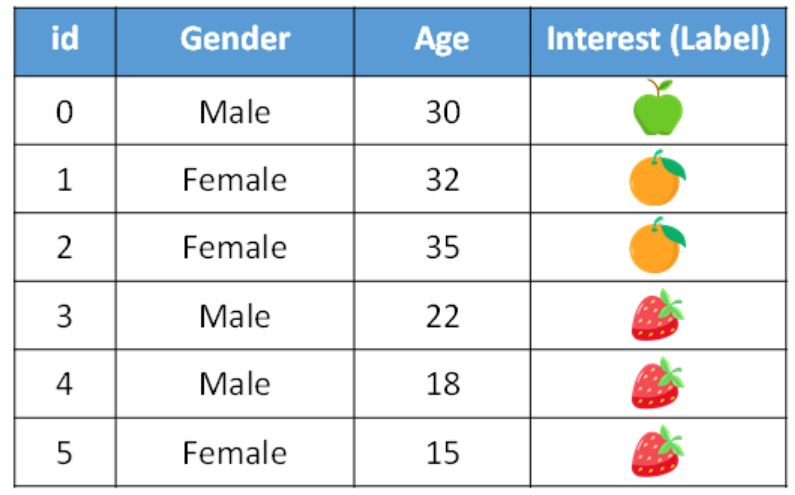

Độ không thuần khiết (Impurity) của dữ liệu


- Entropy
- Information Gain (IG)


Entropy


$$
\Large Entropy = \sum_{i=1}^{n} p_i.log_2 \biggl(\frac{1}{p_i} \biggr) = \sum_{i=1}^{n} -p_i.log_2 (p_i)
$$


Giá trị entropy càng lớn thì độ impurity càng cao



Information Gain (IG)
$$
\begin{align}
\Large IG_{entropy} &= \Large E(parent) - \sum_{i=1}^{n} w_{i}\times E(child_{i})
\end{align}
$$

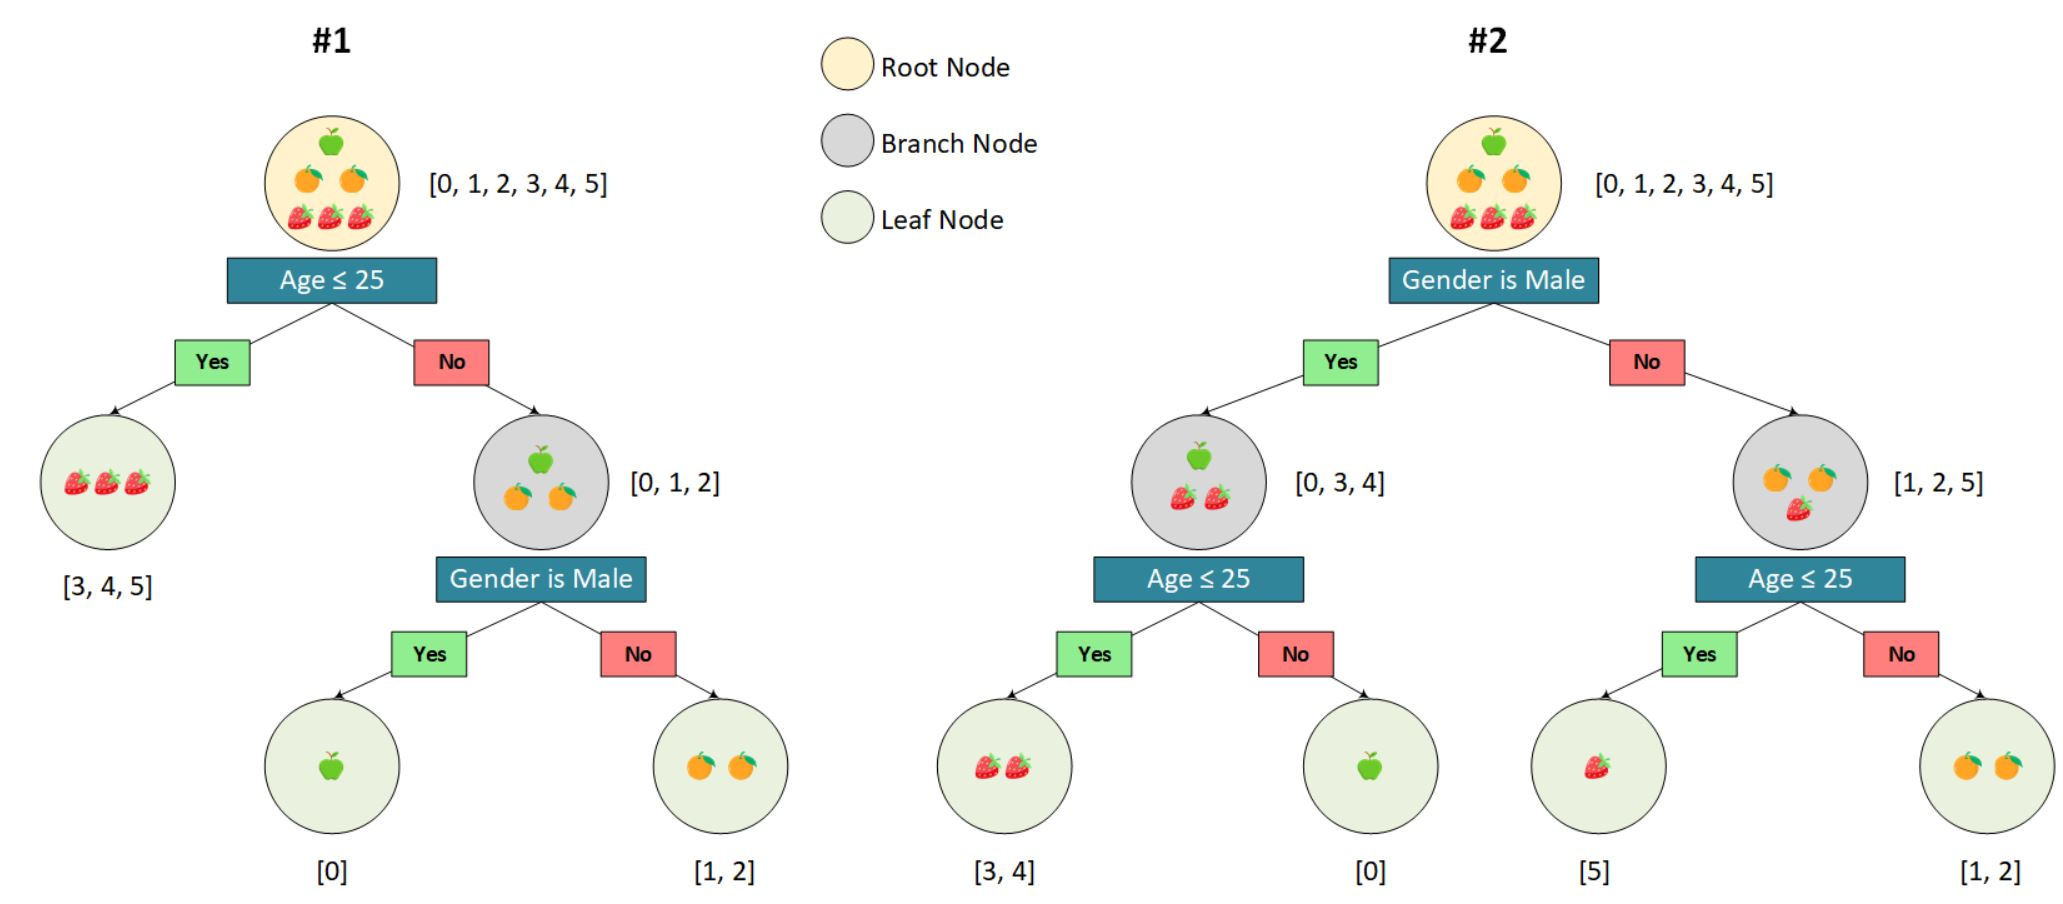

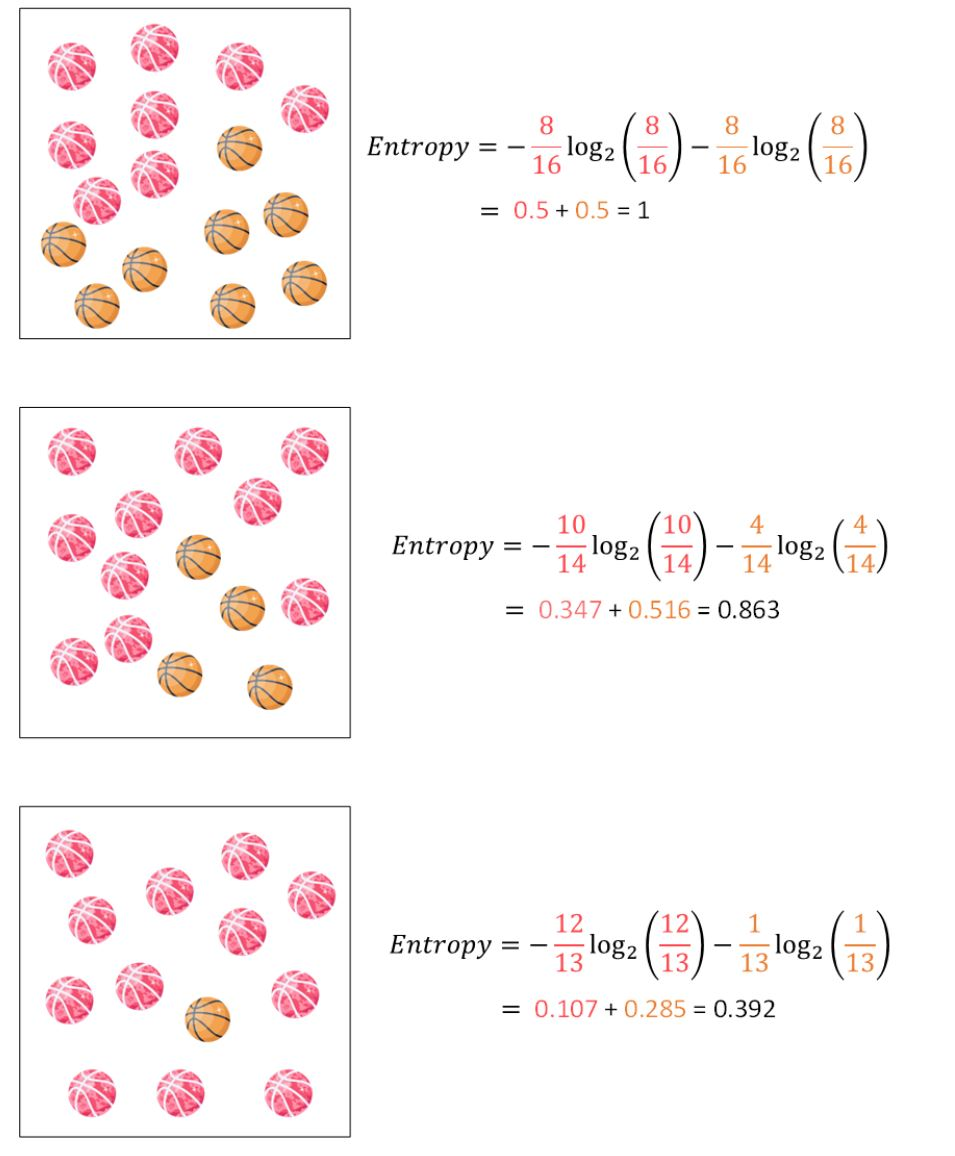

## 1. Nạp dữ liệu

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Nạp dữ liệu

In [24]:
dataset = pd.read_csv('/content/Game.csv')
dataset.head(5)

,X1,X2,Y
0,1,1,1
1,2,1,1
2,3,1,1
3,4,1,1
4,5,1,1


In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      36 non-null     int64
 1   X2      36 non-null     int64
 2   Y       36 non-null     int64
dtypes: int64(3)
memory usage: 996.0 bytes


In [26]:
dataset.describe()

,X1,X2,Y
count,36.000000,36.000000,36.000000
mean,3.500000,3.500000,0.888889
std,1.732051,1.732051,0.318728
min,1.000000,1.000000,0.000000
25%,2.000000,2.000000,1.000000
50%,3.500000,3.500000,1.000000
75%,5.000000,5.000000,1.000000
max,6.000000,6.000000,1.000000


## 3. Tách biến độc lập và biến phụ thuôc

In [27]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [28]:
X.head(5)

,X1,X2
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [29]:
y.head(5)

,Y
0,1
1,1
2,1
3,1
4,1


## 4. Trực quan hóa dữ liệu

In [30]:
#lọc ra tất cả các hàng sao cho y =1
dataset.loc[ (dataset['Y'] ==1) , :]

,X1,X2,Y
0,1,1,1
1,2,1,1
2,3,1,1
3,4,1,1
4,5,1,1
5,6,1,1
8,3,2,1
9,4,2,1
10,5,2,1
11,6,2,1


In [32]:
X1_class1 = dataset.loc[dataset['Y']==1 , 'X1']
X2_class1 = dataset.loc[dataset['Y']==1 , 'X2']

X1_class0 = dataset.loc[dataset['Y']==0 , 'X1']
X2_class0 = dataset.loc[dataset['Y']==0,'X2']

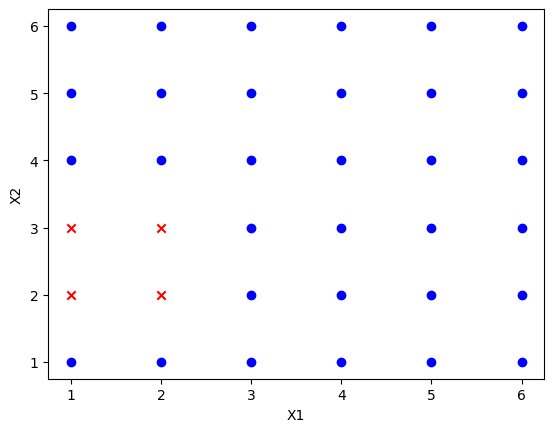

In [33]:
plt.scatter(X1_class1,X2_class1,color='blue',marker='o')
plt.scatter(X1_class0,X2_class0,color='red',marker='x')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## 5. Huấn luyện mô hình Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy') #criterion = 'gini'
classifier.fit(X,y)

DecisionTreeClassifier(criterion='entropy')

## 6. Trực quan hóa cây quyết định

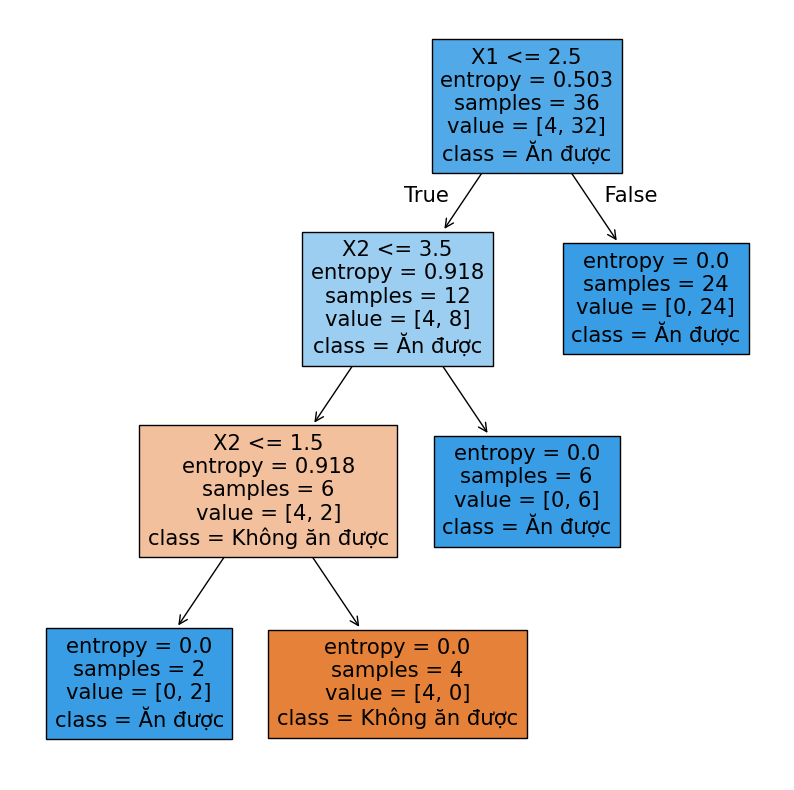

In [36]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(classifier,filled=True,class_names=['Không ăn được','Ăn được'],feature_names=X.columns)
plt.show()

## 7. Trực quan hóa đường biên phân lớp

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


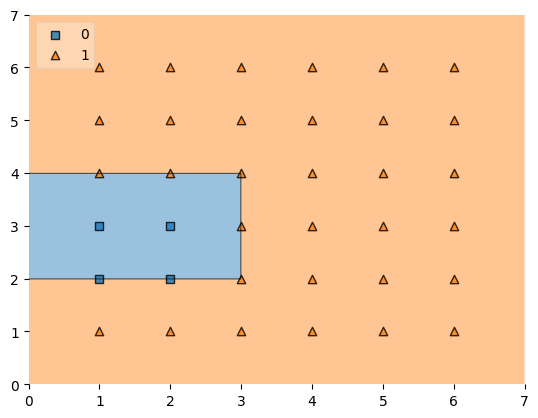

In [39]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,clf=classifier,legend =2)
plt.show()

Text(0, 0.5, 'X2')

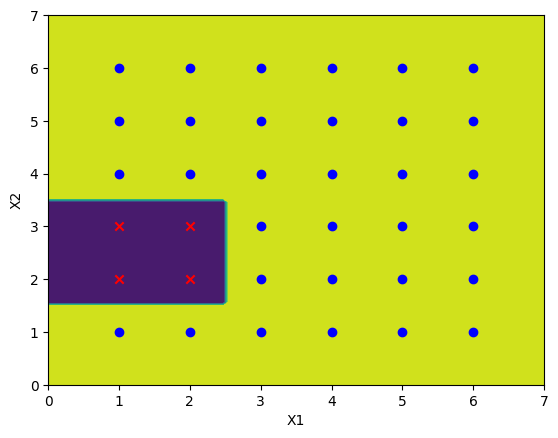

In [41]:
from sklearn.inspection import DecisionBoundaryDisplay
DecisionBoundaryDisplay.from_estimator(classifier,X,response_method='predict')
plt.scatter(X1_class1,X2_class1,color='blue',marker='o')
plt.scatter(X1_class0,X2_class0,color='red',marker='x')
plt.xlabel('X1')
plt.ylabel('X2')